# Paris Airbnb Review Intelligence Pipeline

## Objective 
Convert unstructured Airbnb guest reviews into concise, factual, structured property profiles that help a portfolio manager understand recurring strengths, weaknesses, and guest-experience themes.

This notebook implements the three components requested in the challenge:

1. **Text preparation** for a reasoning LLM, with explicit attention to signal preservation and token cost.
2. **Structured LLM extraction**, including prompt iteration, parsing, schema validation, and failure handling.
3. **Reliability, scale, cost, and human-review analysis** grounded in the observed experiment.

### Executive result

The strongest production design is not simply “send every review to an LLM.” A conservative cleaning step preserves guest signal, while a 30-review temporal cap controls the long tail of very large listings. In the manual audit, extraction quality was strongest when enough review evidence was available and weakest for listings with only one or two reviews. The recommended production system therefore combines the final prompt with deterministic validation, retries, checkpointing, and low-evidence routing.

> **Reproducibility:** Place `reviews.csv.gz` at `data/reviews.csv.gz`. For live Gemini calls, create a local `.env` file containing `GEMINI_API_KEY=...`. Never commit `.env`.

## 1. Setup and configuration

The notebook uses only the columns required for this task (`listing_id`, `id`, `date`, `comments`) to reduce memory use. Reviewer identifiers and names are not needed to construct property-level profiles.

### LLM API configuration
The LLM sections are written so the notebook can still run without an API key. If a key is available, `RUN_LLM` can be set to `True` to reproduce live extraction calls.

The notebook includes the outputs from the evaluated Gemini experiment.

Live LLM calls are optional. To reproduce them, create a local `.env` file
in the project directory containing:

`GEMINI_API_KEY=your_api_key`

The API key is intentionally not included in the submission.

If no API key is available, the notebook uses the saved experiment results
for the downstream reliability and production analyses.

In [75]:
from pathlib import Path
import json
import os
import re
import time
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

DATA_PATH = Path("data/reviews.csv.gz")
RANDOM_SEED = 42
MAX_REVIEWS_PER_LISTING = 30

MODEL_NAME = "gemini-3.6-flash"
API_KEY = os.getenv("GEMINI_API_KEY")
# RUN_LLM = bool(API_KEY)  # Set False to avoid live API calls even when a key is present.
RUN_LLM = False

print("Data path:", DATA_PATH)
print("Live LLM calls enabled:", RUN_LLM)

Data path: data/reviews.csv.gz
Live LLM calls enabled: False


### Dependencies

A minimal environment is sufficient:

```bash
pip install pandas numpy matplotlib python-dotenv google-genai
```

The data file is intentionally not embedded in the notebook. This keeps the submission lightweight and mirrors a production workflow where data and credentials are external inputs.

## 2. Load and understand the raw review corpus

Before cleaning anything, I measure the corpus. Preparation decisions should be justified by the actual data rather than by generic NLP preprocessing conventions.

In [42]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Expected dataset at {DATA_PATH}. "
        "Download the Paris reviews file from Inside Airbnb and place it there."
    )

reviews = pd.read_csv(
    DATA_PATH,
    compression="infer",
    usecols=["listing_id", "id", "date", "comments"],
    dtype={
        "listing_id": "int64",
        "id": "int64",
        "date": "string",
        "comments": "string",
    },
)

reviews["date"] = pd.to_datetime(reviews["date"], errors="coerce")
reviews["review_length_chars"] = reviews["comments"].fillna("").str.len()
reviews["review_length_words"] = reviews["comments"].fillna("").str.split().str.len()

raw_stats = pd.Series({
    "reviews": len(reviews),
    "unique_listings": reviews["listing_id"].nunique(),
    "missing_comments": reviews["comments"].isna().sum(),
    "empty_comments": reviews["comments"].fillna("").str.strip().eq("").sum(),
    "median_review_chars": reviews["review_length_chars"].median(),
    "p90_review_chars": reviews["review_length_chars"].quantile(0.90),
    "date_min": reviews["date"].min(),
    "date_max": reviews["date"].max(),
})

raw_stats

reviews                            2404369
unique_listings                      61781
missing_comments                       147
empty_comments                         147
median_review_chars                  189.0
p90_review_chars                     553.0
date_min               2010-01-26 00:00:00
date_max               2026-06-28 00:00:00
dtype: object

In [43]:
reviews_per_listing = reviews.groupby("listing_id").size()

listing_distribution = reviews_per_listing.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).round(1)

listing_distribution

count    61781.0
mean        38.9
std         73.0
min          1.0
25%          5.0
50%         16.0
75%         43.0
90%         95.0
95%        150.0
99%        349.0
max       4589.0
dtype: float64

**Observed development-run context:** the corpus contained about **2.4 million reviews across 61,781 listings**. Review volume was highly skewed: the median listing had 16 reviews, while the largest listing had thousands. That skew is important because sending every review to the model makes latency and token cost dominated by a small number of extreme listings.

## 3. Conservative text preparation

I avoid aggressive normalization such as stemming, stop-word removal, or translation. Those operations can erase useful guest signals, tone, negation, and multilingual detail.

The cleaning step only:

- drops missing/empty review text,
- normalizes HTML line breaks and whitespace,
- removes **exact duplicate review text within the same listing**.

The duplicate rule is listing-scoped because identical short phrases can legitimately occur across different properties.

In [44]:
def clean_review_text(text: str) -> str:
    text = str(text)
    text = re.sub(r"<br\s*/?>", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


clean_reviews = reviews.dropna(subset=["comments"]).copy()
clean_reviews["clean_comments"] = clean_reviews["comments"].map(clean_review_text)
clean_reviews = clean_reviews[clean_reviews["clean_comments"].str.len() > 0].copy()

clean_reviews = clean_reviews.drop_duplicates(
    subset=["listing_id", "clean_comments"]
).copy()

clean_reviews["review_length_chars"] = clean_reviews["clean_comments"].str.len()
clean_reviews["review_length_words"] = clean_reviews["clean_comments"].str.split().str.len()

cleaning_summary = pd.DataFrame({
    "stage": ["Raw", "Cleaned"],
    "reviews": [len(reviews), len(clean_reviews)],
    "unique_listings": [
        reviews["listing_id"].nunique(),
        clean_reviews["listing_id"].nunique(),
    ],
})

cleaning_summary["reduction_vs_raw_pct"] = (
    1 - cleaning_summary["reviews"] / len(reviews)
) * 100

cleaning_summary.round(2)

,stage,reviews,unique_listings,reduction_vs_raw_pct
0,Raw,2404369,61781,0.00
1,Cleaned,2401567,61781,0.12


The cleaning reduction is intentionally small. That is a feature, not a weakness: the objective is to remove obvious noise without deleting substantive guest evidence.

## 4. Cost-aware review sampling

The model does not need thousands of reviews from a single property to form a useful profile. I cap each listing at **30 reviews**, but select them **across time** rather than taking only the newest or oldest reviews.

This choice:

- preserves temporal coverage,
- leaves smaller listings untouched,
- sharply reduces long-tail token cost,
- keeps per-listing input size more predictable.

The cap is a pragmatic engineering choice, not a claim that 30 is universally optimal. A production system should tune it against quality and cost.

In [45]:
def sample_reviews_across_time(
    group: pd.DataFrame,
    max_reviews: int = MAX_REVIEWS_PER_LISTING,
) -> pd.DataFrame:
    group = group.sort_values("date").copy()

    if len(group) <= max_reviews:
        return group

    positions = np.linspace(
        0,
        len(group) - 1,
        max_reviews,
        dtype=int,
    )
    return group.iloc[positions].copy()


sampled_parts = [
    sample_reviews_across_time(group)
    for _, group in clean_reviews.groupby("listing_id", sort=False)
]

sampled_reviews = pd.concat(sampled_parts, ignore_index=True)

listing_stats = (
    clean_reviews.groupby("listing_id")
    .agg(
        review_count=("clean_comments", "size"),
        total_words=("review_length_words", "sum"),
        avg_review_words=("review_length_words", "mean"),
    )
)

sampled_listing_stats = (
    sampled_reviews.groupby("listing_id")
    .agg(
        review_count=("clean_comments", "size"),
        total_words=("review_length_words", "sum"),
        avg_review_words=("review_length_words", "mean"),
    )
)

sampled_listing_stats.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).round(1)

,review_count,total_words,avg_review_words
count,61781.0,61781.0,61781.0
mean,16.7,738.9,44.7
std,11.6,580.0,22.0
min,1.0,1.0,1.0
25%,5.0,200.0,32.0
50%,16.0,665.0,41.8
75%,30.0,1173.0,53.3
90%,30.0,1522.0,68.0
95%,30.0,1737.0,81.0
99%,30.0,2222.2,125.0


## 5. Experimental sample

Free-tier usage limits make a full-corpus LLM evaluation unnecessary for this exercise. I build a small **stratified sample of 15 listings** so the prompt is tested under different evidence conditions:

- **Low evidence:** 1–5 sampled reviews
- **Medium evidence:** 10–20 sampled reviews
- **High evidence:** 30 sampled reviews

Using a fixed seed makes the selection reproducible.

In [46]:
low_pool = sampled_listing_stats[
    sampled_listing_stats["review_count"].between(1, 5)
]
medium_pool = sampled_listing_stats[
    sampled_listing_stats["review_count"].between(10, 20)
]
high_pool = sampled_listing_stats[
    sampled_listing_stats["review_count"].eq(30)
]

low_sample = low_pool.sample(n=5, random_state=RANDOM_SEED)
medium_sample = medium_pool.sample(n=5, random_state=RANDOM_SEED)
high_sample = high_pool.sample(n=5, random_state=RANDOM_SEED)

experiment_listing_ids = (
    low_sample.index.tolist()
    + medium_sample.index.tolist()
    + high_sample.index.tolist()
)

experiment_reviews = sampled_reviews[
    sampled_reviews["listing_id"].isin(experiment_listing_ids)
].copy()

experiment_summary = (
    experiment_reviews.groupby("listing_id")
    .size()
    .rename("review_count")
    .to_frame()
)

experiment_summary["evidence_level"] = pd.cut(
    experiment_summary["review_count"],
    bins=[0, 5, 20, np.inf],
    labels=["low", "medium", "high"],
)

experiment_summary

,review_count,evidence_level
listing_id,,
4518417,30,high
7969675,30,high
26807634,20,medium
31355683,2,low
739093236179136797,30,high
750654512060290549,30,high
761427919129626193,14,medium
854147646638952613,30,high
864416439365207268,12,medium


## 6. Structured property profile

Manual review of low-, medium-, and high-volume listings suggested six categories that are both useful to a portfolio manager and frequently discussed by guests:

- location
- cleanliness
- host experience
- comfort and space
- noise
- amenities

Each category receives a sentiment label plus a concise evidence-grounded summary. The profile also contains recurring strengths, recurring complaints, and an overall summary.

Allowed labels:

`positive`, `mixed`, `negative`, `insufficient_evidence`

In [47]:
CATEGORY_FIELDS = [
    "location",
    "cleanliness",
    "host_experience",
    "comfort_and_space",
    "noise",
    "amenities",
]

REQUIRED_FIELDS = [
    "listing_id",
    *CATEGORY_FIELDS,
    "recurring_strengths",
    "recurring_complaints",
    "overall_summary",
]

ALLOWED_SENTIMENTS = {
    "positive",
    "mixed",
    "negative",
    "insufficient_evidence",
}

PROFILE_SCHEMA = {
    "listing_id": "",
    **{
        field: {"sentiment": "", "summary": ""}
        for field in CATEGORY_FIELDS
    },
    "recurring_strengths": [],
    "recurring_complaints": [],
    "overall_summary": "",
}

PROFILE_SCHEMA

{'listing_id': '',
 'location': {'sentiment': '', 'summary': ''},
 'cleanliness': {'sentiment': '', 'summary': ''},
 'host_experience': {'sentiment': '', 'summary': ''},
 'comfort_and_space': {'sentiment': '', 'summary': ''},
 'noise': {'sentiment': '', 'summary': ''},
 'amenities': {'sentiment': '', 'summary': ''},
 'recurring_strengths': [],
 'recurring_complaints': [],
 'overall_summary': ''}

## 7. Prompt engineering: V1 → V3

Prompt iteration was driven by observed failure modes rather than cosmetic rewriting.

| Version | Change | Observation | Decision |
|---|---|---|---|
| **V1** | Evidence-only instruction + fixed JSON schema | Structurally valid, but a meaningful comfort/space tradeoff was labeled fully positive | Clarify sentiment semantics |
| **V2** | Defined `positive`, `mixed`, `negative`, `insufficient_evidence` | Tradeoff was still labeled positive | Add an explicit tradeoff rule and example |
| **V3** | Explicitly requires `mixed` when a meaningful limitation coexists with positive evidence | Corrected the tested tradeoff and behaved well on a high-evidence listing | Selected as final prompt |
| **Sparse-evidence test** | Tested stricter wording on a one-review property | Model could still be overconfident | Handle sparse evidence deterministically outside the prompt |

This is an important production lesson: prompt wording can improve behavior, but some reliability constraints are better enforced by pipeline logic.

In [48]:
PROMPT_V3 = """
You are analyzing Airbnb guest reviews for one property.

Create a concise and factual property profile using only information
explicitly stated in the reviews.

For each category, choose exactly one sentiment label:

- positive:
  The reviews are clearly favorable for this category and contain no meaningful
  drawback, limitation, or negative evidence.

- mixed:
  The reviews contain both positive and negative evidence, OR describe a
  meaningful tradeoff, limitation, or drawback within the category.

  Important:
  If guests describe something positively but also mention a meaningful
  limitation, do NOT label the category as positive. Use "mixed".

  Example:
  "Comfortable and functional, but very small and best for two guests"
  should be labeled "mixed", not "positive".

- negative:
  The available evidence is clearly unfavorable for this category.

- insufficient_evidence:
  The reviews do not discuss the category enough to support a reliable judgment.

Return valid JSON with exactly this structure:

{{
  "listing_id": "{listing_id}",
  "location": {{"sentiment": "", "summary": ""}},
  "cleanliness": {{"sentiment": "", "summary": ""}},
  "host_experience": {{"sentiment": "", "summary": ""}},
  "comfort_and_space": {{"sentiment": "", "summary": ""}},
  "noise": {{"sentiment": "", "summary": ""}},
  "amenities": {{"sentiment": "", "summary": ""}},
  "recurring_strengths": [],
  "recurring_complaints": [],
  "overall_summary": ""
}}

Rules:
- Use only the provided reviews.
- Do not invent or infer unsupported facts.
- A "positive" label requires no meaningful negative evidence in that category.
- If a category has a clear tradeoff or limitation, use "mixed".
- Do not treat a single isolated issue as a recurring complaint unless it appears
  as part of a broader pattern.
- If evidence is weak or absent, use "insufficient_evidence".
- Keep summaries concise and factual.
- Return JSON only.

Listing ID:
{listing_id}

Reviews:
{reviews_text}
"""

## 8. Prompt construction, API call, parsing, and validation

These functions form the reusable extraction boundary. The API response is never accepted directly: it is cleaned, parsed, and validated first.

In [49]:
def build_prompt_for_listing(
    listing_id: int,
    prompt_template: str = PROMPT_V3,
) -> str:
    listing_reviews = (
        experiment_reviews[
            experiment_reviews["listing_id"] == listing_id
        ]
        .sort_values("date")
    )

    reviews_text = "\n".join(
        f"Review {i}: {text}"
        for i, text in enumerate(
            listing_reviews["clean_comments"],
            start=1,
        )
    )

    return prompt_template.format(
        listing_id=listing_id,
        reviews_text=reviews_text,
    )


def clean_llm_response(text: str) -> str:
    text = text.strip()
    text = re.sub(r"^```(?:json)?\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s*```$", "", text)
    return text.strip()


def validate_profile(profile: dict[str, Any]) -> dict[str, list]:
    missing_fields = [
        field for field in REQUIRED_FIELDS
        if field not in profile
    ]

    invalid_sentiments = []
    malformed_categories = []

    for field in CATEGORY_FIELDS:
        value = profile.get(field)

        if not isinstance(value, dict):
            malformed_categories.append(field)
            continue

        sentiment = value.get("sentiment")
        summary = value.get("summary")

        if sentiment not in ALLOWED_SENTIMENTS:
            invalid_sentiments.append((field, sentiment))

        if not isinstance(summary, str):
            malformed_categories.append(field)

    return {
        "missing_fields": missing_fields,
        "invalid_sentiments": invalid_sentiments,
        "malformed_categories": malformed_categories,
    }

In [50]:
client = None

if RUN_LLM:
    from google import genai
    client = genai.Client(api_key=API_KEY)


def generate_profile(listing_id: int) -> tuple[dict, dict]:
    if client is None:
        raise RuntimeError(
            "Live LLM calls are disabled. Set GEMINI_API_KEY and RUN_LLM=True."
        )

    prompt = build_prompt_for_listing(listing_id)

    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=prompt,
    )

    cleaned_text = clean_llm_response(response.text)
    profile = json.loads(cleaned_text)
    validation = validate_profile(profile)

    return profile, validation

## 9. Batch extraction with checkpoint-style failure isolation

A production batch should not fail because one listing returns a temporary error or malformed response. Each listing is isolated in `try/except`, and successful results are retained independently.

The live cell below is intentionally conditional. This makes the notebook runnable without consuming API quota during review.

In [51]:
results = []
failures = []

if RUN_LLM:
    for listing_id in experiment_listing_ids:
        try:
            profile, validation = generate_profile(listing_id)

            review_count = int(
                (experiment_reviews["listing_id"] == listing_id).sum()
            )

            results.append({
                "listing_id": listing_id,
                "review_count": review_count,
                "low_evidence": review_count < 3,
                "profile": profile,
                **validation,
            })

        except Exception as exc:
            failures.append({
                "listing_id": listing_id,
                "error": str(exc),
            })

    print("Successful extractions:", len(results))
    print("Failures:", len(failures))
else:
    print(
        "Live batch skipped. The reliability analysis below uses the "
        "observed development-run results documented during the experiment."
    )

Successful extractions: 15
Failures: 0


### Observed development-run reliability

The final 15-listing batch completed successfully for all **15 listings**, with
**15 successful extractions and 0 API failures**.

All successful responses:

- parsed successfully as JSON,
- contained the required schema fields,
- and used valid sentiment labels.

Earlier development runs encountered `429 RESOURCE_EXHAUSTED` quota errors and one
temporary `503` service-availability error. These were operational API failures rather
than structured-extraction failures. After rerunning with available API quota, all
15 requests completed successfully.

This distinction is important: API availability and model extraction quality are
separate reliability dimensions.

In [62]:
observed_batch = pd.DataFrame({
    "metric": [
        "attempted",
        "successful",
        "failed",
        "api_success_rate_pct",
        "schema_success_rate_pct",
        "valid_sentiment_rate_pct",
        "low_evidence_successes",
    ],
    "value": [
        len(experiment_listing_ids),
        len(results),
        len(failures),
        round(len(results) / len(experiment_listing_ids) * 100, 1),
        round(
            sum(
                len(r["missing_fields"]) == 0
                and len(r["malformed_categories"]) == 0
                for r in results
            ) / len(results) * 100,
            1
        ) if results else 0,
        round(
            sum(
                len(r["invalid_sentiments"]) == 0
                for r in results
            ) / len(results) * 100,
            1
        ) if results else 0,
        sum(r["low_evidence"] for r in results),
    ],
})

observed_batch

,metric,value
0,attempted,15.0
1,successful,15.0
2,failed,0.0
3,api_success_rate_pct,100.0
4,schema_success_rate_pct,100.0
5,valid_sentiment_rate_pct,100.0
6,low_evidence_successes,4.0


## 10. Manual factual quality evaluation

Structural validity does not prove factual correctness. I therefore manually audited **36 category-level judgments across six listings**, stratified by evidence volume.

Audit labels:

- **supported** — sentiment and summary are clearly grounded in the reviews
- **partially_supported** — the main idea is grounded, but the output overgeneralizes, misses a tradeoff, or bundles supported and unsupported aspects
- **unsupported** — the output makes a claim not supported by the source reviews

Because this is a human audit, the labels are stored explicitly rather than regenerated by another LLM.

In [63]:
audit_rows = []

def add_audit(listing_id, review_count, labels):
    for field, support in labels.items():
        audit_rows.append({
            "listing_id": listing_id,
            "review_count": review_count,
            "field": field,
            "support": support,
        })

# Low evidence
add_audit(
    993243488059183100, 1,
    {
        "location": "partially_supported",
        "cleanliness": "supported",
        "host_experience": "supported",
        "comfort_and_space": "partially_supported",
        "noise": "supported",
        "amenities": "supported",
    },
)

add_audit(
    1681716594698579946, 2,
    {
        "location": "supported",
        "cleanliness": "supported",
        "host_experience": "unsupported",
        "comfort_and_space": "supported",
        "noise": "supported",
        "amenities": "supported",
    },
)

# Medium evidence
add_audit(
    761427919129626193, 14,
    {
        "location": "supported",
        "cleanliness": "supported",
        "host_experience": "supported",
        "comfort_and_space": "supported",
        "noise": "supported",
        "amenities": "supported",
    },
)

add_audit(
    1362095752304882006, 14,
    {
        "location": "supported",
        "cleanliness": "supported",
        "host_experience": "supported",
        "comfort_and_space": "partially_supported",
        "noise": "supported",
        "amenities": "supported",
    },
)

# High evidence
add_audit(
    739093236179136797, 30,
    {field: "supported" for field in CATEGORY_FIELDS},
)

add_audit(
    7969675, 30,
    {field: "supported" for field in CATEGORY_FIELDS},
)

manual_quality_eval = pd.DataFrame(audit_rows)

quality_rates = (
    manual_quality_eval["support"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

quality_rates

support
supported              88.9
partially_supported     8.3
unsupported             2.8
Name: proportion, dtype: float64

**Observed manual-audit result**

- **88.9% supported**
- **8.3% partially supported**
- **2.8% unsupported**

The unsupported claim occurred in a low-evidence listing, which motivated an explicit production safeguard rather than another round of prompt tuning.

## 11. Quality by evidence level

The audit suggests that evidence volume is an important reliability signal. This analysis is descriptive rather than a statistically powered benchmark, but the pattern is operationally useful.

In [64]:
def evidence_level(review_count: int) -> str:
    if review_count < 3:
        return "low"
    if review_count <= 20:
        return "medium"
    return "high"


manual_quality_eval["evidence_level"] = (
    manual_quality_eval["review_count"].map(evidence_level)
)

quality_by_evidence = (
    manual_quality_eval
    .groupby(["evidence_level", "support"])
    .size()
    .unstack(fill_value=0)
)

quality_by_evidence_pct = (
    quality_by_evidence
    .div(quality_by_evidence.sum(axis=1), axis=0)
    .mul(100)
    .round(1)
)

quality_by_evidence_pct

support,partially_supported,supported,unsupported
evidence_level,,,
high,0.0,100.0,0.0
low,16.7,75.0,8.3
medium,8.3,91.7,0.0


The observed pattern was:

- **High evidence:** 100% supported
- **Medium evidence:** 91.7% supported, 8.3% partially supported
- **Low evidence:** 75.0% supported, 16.7% partially supported, 8.3% unsupported

This is why the production recommendation flags listings with fewer than three reviews for human review.

## 12. Impact of review preparation

Two effects should be separated:

1. Cleaning removes obvious noise but intentionally changes little.
2. Sampling is the main cost-control mechanism.

The charts below make that distinction visible.

In [65]:
prep_summary = pd.DataFrame({
    "stage": ["Raw", "Cleaned", "Sampled"],
    "review_count": [
        len(reviews),
        len(clean_reviews),
        len(sampled_reviews),
    ],
})

prep_summary["reduction_vs_raw_pct"] = (
    1 - prep_summary["review_count"] / len(reviews)
) * 100

word_summary = pd.DataFrame({
    "stage": ["Raw", "Cleaned", "Sampled"],
    "total_words": [
        reviews["review_length_words"].sum(),
        clean_reviews["review_length_words"].sum(),
        sampled_reviews["review_length_words"].sum(),
    ],
})

word_summary["reduction_vs_raw_pct"] = (
    1 - word_summary["total_words"] / word_summary.loc[0, "total_words"]
) * 100

display(prep_summary.round(2))
display(word_summary.round(2))

,stage,review_count,reduction_vs_raw_pct
0,Raw,2404369,0.00
1,Cleaned,2401567,0.12
2,Sampled,1032693,57.05


,stage,total_words,reduction_vs_raw_pct
0,Raw,103790359,0.00
1,Cleaned,104486371,-0.67
2,Sampled,45649475,56.02


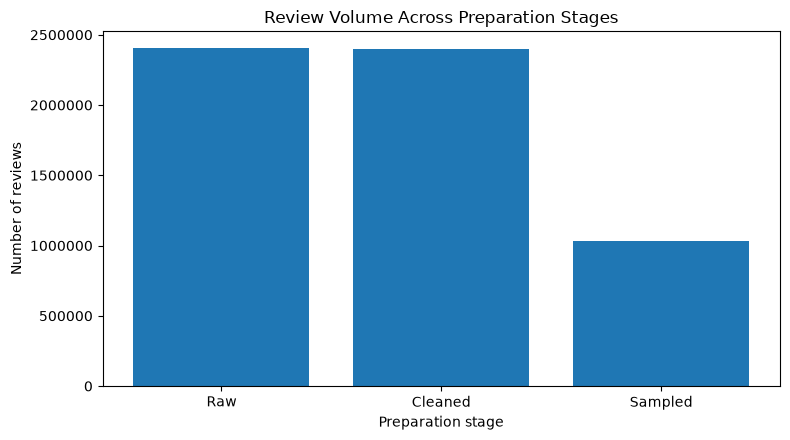

In [66]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(prep_summary["stage"], prep_summary["review_count"])
ax.set_title("Review Volume Across Preparation Stages")
ax.set_xlabel("Preparation stage")
ax.set_ylabel("Number of reviews")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

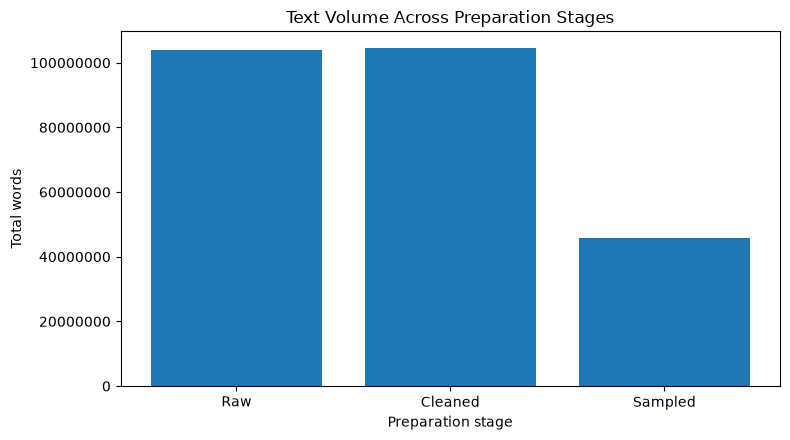

In [67]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(word_summary["stage"], word_summary["total_words"])
ax.set_title("Text Volume Across Preparation Stages")
ax.set_xlabel("Preparation stage")
ax.set_ylabel("Total words")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

In [68]:
before_after_listing_words = pd.DataFrame({
    "Before sampling": listing_stats["total_words"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ),
    "After sampling": sampled_listing_stats["total_words"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ),
})

before_after_listing_words

,Before sampling,After sampling
count,61781.000000,61781.000000
mean,1691.237937,738.891811
std,3043.667229,580.012740
min,1.000000,1.000000
50%,681.000000,665.000000
75%,1870.000000,1173.000000
90%,4162.000000,1522.000000
95%,6731.000000,1737.000000
99%,15048.200000,2222.200000
max,127506.000000,4618.000000


**Observed preparation impact**

- cleaning removed only about **0.12%** of review rows;
- the 30-review temporal cap reduced total review volume by about **57%**;
- sampled text volume fell by about **56%**;
- median words per listing changed only slightly (**681 → 665**);
- the maximum fell dramatically (**127,506 → 4,618 words**).

The slight increase in whitespace-based word count after cleaning is expected: replacing HTML line breaks and formatting artifacts with spaces can separate previously joined tokens.

The important result is that sampling compresses the **long tail** while leaving a typical listing mostly intact.

## 13. Token and cost estimate for 10,000 listings

The estimate uses the sampled corpus because that is the proposed production input.

Assumptions are explicit:

- approximate multilingual conversion: **1 word ≈ 1.4 tokens**
- estimated billed output: **800 tokens/listing**
- pricing assumptions used in this analysis: **$0.75/M input tokens** and **$3.75/M output tokens**
- **10%** retry allowance for planning

Pricing and tokenization should be revalidated before deployment; this is an order-of-magnitude planning estimate.

In [69]:
avg_review_words = sampled_listing_stats["total_words"].mean()

prompt_overhead = PROMPT_V3.format(
    listing_id="LISTING_ID",
    reviews_text="",
)
prompt_overhead_words = len(prompt_overhead.split())

TOKENS_PER_WORD = 1.4
ESTIMATED_OUTPUT_TOKENS = 800
N_LISTINGS = 10_000

INPUT_PRICE_PER_MILLION = 0.75
OUTPUT_PRICE_PER_MILLION = 3.75
RETRY_OVERHEAD = 0.10

avg_input_words = avg_review_words + prompt_overhead_words
avg_input_tokens = avg_input_words * TOKENS_PER_WORD

total_input_tokens = avg_input_tokens * N_LISTINGS
total_output_tokens = ESTIMATED_OUTPUT_TOKENS * N_LISTINGS

input_cost = (
    total_input_tokens / 1_000_000
) * INPUT_PRICE_PER_MILLION

output_cost = (
    total_output_tokens / 1_000_000
) * OUTPUT_PRICE_PER_MILLION

estimated_total_cost = input_cost + output_cost
estimated_cost_with_retries = estimated_total_cost * (1 + RETRY_OVERHEAD)

cost_summary = pd.DataFrame({
    "metric": [
        "Average review words / listing",
        "Prompt overhead words",
        "Estimated input tokens / listing",
        "Estimated output tokens / listing",
        "Total input tokens (10k)",
        "Total output tokens (10k)",
        "Input cost",
        "Output cost",
        "Estimated total cost",
        "Total with 10% retry overhead",
    ],
    "value": [
        round(avg_review_words, 1),
        prompt_overhead_words,
        round(avg_input_tokens),
        ESTIMATED_OUTPUT_TOKENS,
        round(total_input_tokens),
        round(total_output_tokens),
        f"${input_cost:.2f}",
        f"${output_cost:.2f}",
        f"${estimated_total_cost:.2f}",
        f"${estimated_cost_with_retries:.2f}",
    ],
})

cost_summary

,metric,value
0,Average review words / listing,738.9
1,Prompt overhead words,267
2,Estimated input tokens / listing,1408
3,Estimated output tokens / listing,800
4,Total input tokens (10k),14082485
5,Total output tokens (10k),8000000
6,Input cost,$10.56
7,Output cost,$30.00
8,Estimated total cost,$40.56
9,Total with 10% retry overhead,$44.62


Using the observed corpus statistics, the estimate is approximately **$40.56 for 10,000 listings**, or **$44.62 with a 10% retry allowance**.

The larger production concern is not only token price. Rate limits, retries, checkpointing, and human review of sparse-evidence listings are also material operational considerations.

## 14. Human Review Policy and Production Safeguards

The LLM should not make the final decision by itself. I use deterministic review
rules based on observable pipeline signals rather than asking the model to estimate
its own confidence.

A listing is automatically accepted when:

- there is adequate review evidence,
- JSON parsing succeeds,
- all required schema fields are present,
- all category objects are well formed,
- and all sentiment labels are valid.

A listing is flagged for human review when:

- fewer than 3 reviews are available,
- required schema fields are missing,
- a category is malformed,
- or the model returns an invalid sentiment label.

API failures are handled separately. Temporary `429` or `503` errors should first
be retried with backoff. Only repeated failures should be routed to an operations
or manual-review queue.

The `<3 reviews` rule is motivated by the manual evaluation, where sparse listings
showed weaker factual support than medium- and high-evidence listings.

In [71]:
def needs_human_review(result):
    reasons = []

    if result["review_count"] < 3:
        reasons.append("low_review_count")

    if result["missing_fields"]:
        reasons.append("missing_schema_fields")

    if result["invalid_sentiments"]:
        reasons.append("invalid_sentiment")

    if result["malformed_categories"]:
        reasons.append("malformed_category")

    return bool(reasons), reasons

In [72]:
review_decisions = []

for result in results:
    review_required, reasons = needs_human_review(result)

    review_decisions.append({
        "listing_id": result["listing_id"],
        "review_count": result["review_count"],
        "human_review_required": review_required,
        "review_reasons": reasons,
    })

review_decisions_df = pd.DataFrame(review_decisions)

review_decisions_df

,listing_id,review_count,human_review_required,review_reasons
0,31355683,2,True,[low_review_count]
1,993243488059183100,1,True,[low_review_count]
2,1395758017670800675,2,True,[low_review_count]
3,1681716594698579946,2,True,[low_review_count]
4,1447883311407542674,4,False,[]
5,925982209400670944,11,False,[]
6,761427919129626193,14,False,[]
7,26807634,20,False,[]
8,864416439365207268,12,False,[]
9,1362095752304882006,14,False,[]


In [73]:
human_review_flagged = (
    review_decisions_df["human_review_required"].sum()
    if len(review_decisions_df) > 0
    else 0
)

low_evidence_flagged = (
    review_decisions_df["review_reasons"]
    .apply(lambda reasons: "low_review_count" in reasons)
    .sum()
    if len(review_decisions_df) > 0
    else 0
)

human_review_rate = (
    human_review_flagged / len(review_decisions_df) * 100
    if len(review_decisions_df) > 0
    else 0
)

observed_review_policy = pd.DataFrame({
    "metric": [
        "successful_extractions",
        "human_review_flagged",
        "low_evidence_flagged",
        "human_review_rate_among_successes_pct",
    ],
    "value": [
        len(results),
        human_review_flagged,
        low_evidence_flagged,
        round(human_review_rate, 1),
    ],
})

observed_review_policy

,metric,value
0,successful_extractions,15.0
1,human_review_flagged,4.0
2,low_evidence_flagged,4.0
3,human_review_rate_among_successes_pct,26.7


In [74]:
def classify_failure(error_text):
    error_text = error_text.lower()

    if "429" in error_text or "resource_exhausted" in error_text:
        return "quota_exceeded"

    if "503" in error_text or "unavailable" in error_text:
        return "service_unavailable"

    return "other"


failed_review_queue = pd.DataFrame([
    {
        "listing_id": failure["listing_id"],
        "retry_required": True,
        "failure_type": classify_failure(failure["error"]),
    }
    for failure in failures
])

failed_review_queue

""


### Production Safeguards

A production version of the pipeline should include:

1. **Retry with exponential backoff**  
   Temporary `429` and `503` failures should be retried automatically rather than
   treated as extraction-quality failures.

2. **Quota and rate-limit monitoring**  
   Requests should be paced or deferred when API limits are reached.

3. **Checkpointing**  
   Successful profiles should be persisted immediately so completed listings do not
   need to be processed again after a batch interruption.

4. **Schema validation**  
   Every response should be parsed and validated before being accepted downstream.

5. **Low-evidence routing**  
   Listings with fewer than three reviews should be flagged for human review because
   sparse listings showed weaker factual reliability in the manual evaluation.

6. **Auditability**  
   Source review IDs, prompt version, model version, and final profile should be
   retained so each decision can be traced back to its evidence.

7. **Periodic quality audits**  
   A sample of automatically accepted profiles should still be reviewed periodically
   to detect changes in model behavior or data quality.

## 15. Executive summary for the portfolio manager

### What I found

The Paris review corpus is large, but most of the cost problem is concentrated in a relatively small number of properties with unusually large review histories. Basic cleaning removed almost no substantive data, while a 30-review temporal sample reduced total review volume by about **57%** and total text volume by about **56%**. This made model inputs much more predictable without materially changing the median listing.

The final structured extraction prompt produced usable JSON consistently whenever the API returned a response. In the manual audit of 36 category-level outputs, **88.9% were fully supported**, **8.3% partially supported**, and **2.8% unsupported**.

The clearest reliability risk was sparse evidence. High-evidence listings were fully supported in the small audit, while listings with one or two reviews were more likely to produce conclusions stronger than the source evidence justified.

### What I recommend

Use the LLM pipeline for portfolio-scale review intelligence, but do not treat every property identically:

- automatically process listings with adequate evidence and valid structured output;
- route listings with fewer than three reviews to human review;
- retry temporary API failures automatically;
- retain source reviews and model/prompt metadata for auditability;
- periodically sample accepted profiles for human quality checks.

### Scale

Under the stated token and pricing assumptions, processing **10,000 listings** is estimated at roughly **$40.56**, or about **$44.62** with a 10% retry allowance. The larger production risk is therefore operational reliability and evidence quality rather than raw token cost.

### Bottom line

The approach is practical and low-cost enough for portfolio-level use, provided the LLM is surrounded by deterministic validation, evidence-aware routing, retry logic, and human oversight for sparse or failed cases.

## 16. Limitations and next steps

This is a deliberately scoped take-home experiment, so several limitations should be explicit:

- The manual quality audit covers six listings / 36 category judgments and should not be interpreted as a population-level accuracy estimate.
- The 30-review cap is justified by cost and long-tail control, but it should be tuned with a larger quality study.
- Temporal sampling preserves coverage over time but may miss rare issues that occur only in clustered periods.
- Review language is preserved rather than translated; multilingual model quality can vary by language.
- The cost estimate uses approximate word-to-token conversion and assumed output length rather than per-request billed token telemetry.
- Free-tier 429 errors should not be extrapolated directly to paid production reliability.

### Next steps

1. Build a larger labeled evaluation set with multiple human reviewers.
2. Compare temporal sampling with recency-weighted and diversity-aware sampling.
3. Capture actual API token-usage metadata and latency per request.
4. Add bounded retries, jitter, durable checkpoints, and idempotent batch execution.
5. Track extraction quality by language and evidence volume.
6. Re-evaluate prompt/model changes against a fixed regression suite before deployment.